## Basic Storm Selection 

This notebook shows a presents a basic storm selection algorithm using OMNI data.

In [1]:
import numpy as npy
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt

# %matplotlib widget

In [2]:
def findSeq(X, thres_low, thres_high, thres=0, mlb_time=24 * 60):
    """
    i_inds = findSeq(X, thres_low, thres_high,thres=0)
    Finds the indices of data that corresponds to the sequence crossing lower threshold thres_low, then higher threshold thres_high, and then thres_low again.
    Care should be taken when minima are required. Preceding peaks are included using maximum look back time mlb_time.

    Inputs
    ------
    X: data in numpy array format
    thres_low: lower threshold
    thres_high: high threshold
    thres: threshold for consecutive sequences to be joined, dependent on data sampling rate (default is 0, i.e. no joining unless already joined together)
    mlb_time: maximum look back time to find preceding peaks (default of 24 hours for 1 minute cadence data)

    Returns
    -------
    i_inds: list of indices

    --2014/11/05 12:01-- sl
    --2023/01/18 16:00-- mh
    """

    print("Min / max thresholds are: %.2f , %.2f" % (thres_low, thres_high))

    # find where X < lower | X > high thresholds
    iLH = npy.where((X <= thres_low) | (X >= thres_high))[0]
    x02 = npy.zeros_like(iLH)
    # array to track changes

    # test if any are found
    ithres_high = npy.where(X[iLH] >= thres_high)[0]
    if len(ithres_high) == 0:
        print("No sequences found. Returning [].")
        return []

    x02[ithres_high] = 2

    # use diff to find changes between high and low
    x02_diff = npy.diff(x02)

    if x02[-1] == 2 and x02_diff[-1] == 0:
        print("Last data point to be included.")
        x02_diff[-1] = -2

    i_up = iLH[npy.where(x02_diff == 2)[0]]
    i_down = iLH[npy.where(x02_diff == -2)[0] + 1]

    # Look back mlb_time steps from beginning of sequence and find the minimum, then go back another mlb_time/2 steps. This is to catch the SSC.
    i_up_ssc = i_up.copy()
    for i in range(0, len(i_up)):
        i_up_ssc[i] = (
            npy.argmin(X[(i_up[i] - mlb_time) : i_up[i]])
            + i_up[i]
            - mlb_time
            - mlb_time / 2
        )
        i_up = i_up_ssc
        # if we begin high, then go from beginning
        if i_down[0] < i_up[0]:
            i_up = npy.array([0] + list(i_up), dtype=int)
            N = len(X)
            # if we end high, go to the end
            if i_down[-1:] < i_up[-1:]:
                i_down = npy.array(list(i_down) + [N], dtype=int)

    if len(i_up) != len(i_down):
        print("Error: sequence start and end points do not match.")
    else:
        print("%d sequences found." % (len(i_up)))

    # create array with all selected indices
    i_inds = []
    flag = False
    for i in range(0, len(i_up)):
        if flag == True:
            flag = False
            continue
        if i < len(i_up) - 1:
            if i_up[i + 1] - i_down[i] < thres:
                print(
                    "Joining two sequences next to each other (within the threshold)."
                )
                i_inds.append(range(i_up[i], i_down[i + 1]))
                flag = True
            else:
                i_inds.append(range(i_up[i], i_down[i]))
        else:
            i_inds.append(range(i_up[i], i_down[i]))
        i_inds = list(
            itertools.chain.from_iterable(npy.asarray(a).ravel() for a in i_inds)
        )

    return i_inds

In [3]:
def read_symh(year):
    dat = pd.read_csv(
        "/home/mheyns/2023-FDL-X-Geo/src/DAGGER/omni_omni_min_" + str(year) + ".lst",
        header=None,
        delim_whitespace=True,
        parse_dates=[[0, 1, 2, 3]],
        date_parser=lambda x: dt.datetime.strptime(x, "%Y %j %H %M"),
        usecols=[0, 1, 2, 3, 30],
        index_col=0,
    )
    dat.columns = ["SYM-H"]
    dat.index.name = "datetime"
    return dat

In [4]:
dat2023 = read_symh(2023)
dat2024 = read_symh(2024)
dat = pd.concat([dat2023, dat2024])
dat

/tmp/ipykernel_14949/1408289272.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  dat=pd.read_csv('/home/mheyns/2023-FDL-X-Geo/src/DAGGER/omni_omni_min_'+str(year)+'.lst',header=None,delim_whitespace=True,parse_dates=[[0,1,2,3]],date_parser= lambda x: dt.datetime.strptime(x,'%Y %j %H %M'),usecols=[0,1,2,3,30],index_col=0)
/tmp/ipykernel_14949/1408289272.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv('/home/mheyns/2023-FDL-X-Geo/src/DAGGER/omni_omni_min_'+str(year)+'.lst',header=None,delim_whitespace=True,parse_dates=[[0,1,2,3]],date_parser= lambda x: dt.datetime.strptime(x,'%Y %j %H %M'),usecols=[0,1,2,3,30],index_col=0)
/tmp/ipykernel_14949/1408289272.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future versi

,SYM-H
datetime,
2023-01-01 00:00:00,-21
2023-01-01 00:01:00,-21
2023-01-01 00:02:00,-21
2023-01-01 00:03:00,-21
2023-01-01 00:04:00,-21
...,...
2024-05-31 23:55:00,-28
2024-05-31 23:56:00,-28
2024-05-31 23:57:00,-28


In [5]:
inds_neg = findSeq(-dat["SYM-H"], 10, 50, 6 * 60)

Min / max thresholds are: 10.00 , 50.00
Last data point to be included.
57 sequences found.


/tmp/ipykernel_14949/4189644967.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ithres_high = npy.where(X[iLH] >= thres_high)[0];


Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences next to each other (within the threshold).
Joining two sequences nex

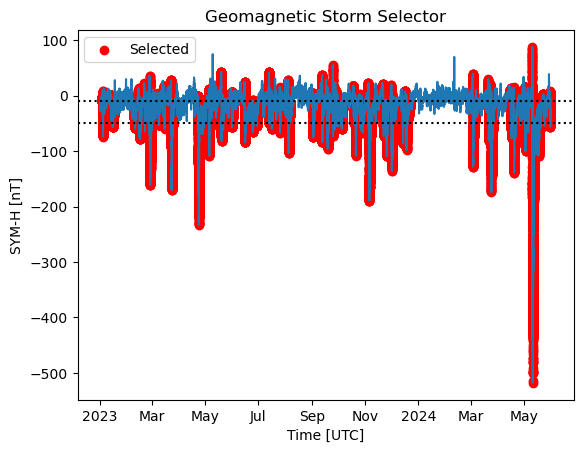

In [6]:
plt.figure()
plt.plot(dat["SYM-H"])
plt.scatter(
    dat.iloc[inds_neg].index, dat["SYM-H"].iloc[inds_neg], color="r", label="Selected"
)
plt.axhline(-10, color="k", linestyle=":")
plt.axhline(-50, color="k", linestyle=":")
plt.title("Geomagnetic Storm Selector")
plt.xlabel("Time [UTC]")
plt.ylabel("SYM-H [nT]")
locator = mdates.AutoDateLocator(minticks=12, maxticks=15)
formatter = mdates.ConciseDateFormatter(locator)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)
plt.legend()
plt.show()

In [7]:
inds_pos = findSeq(dat["SYM-H"], 10, 50, 6 * 60)

Min / max thresholds are: 10.00 , 50.00
4 sequences found.


/tmp/ipykernel_14949/4189644967.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ithres_high = npy.where(X[iLH] >= thres_high)[0];


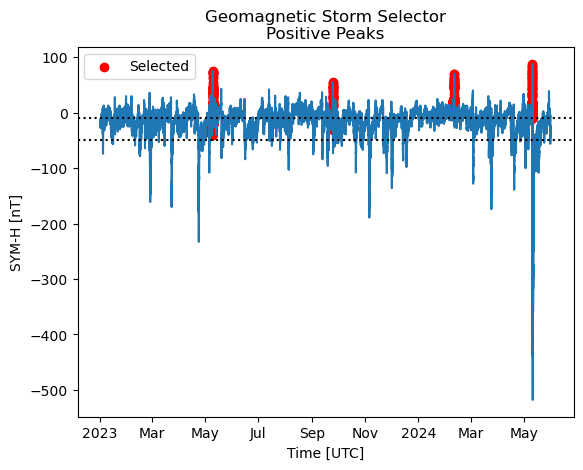

In [8]:
plt.figure()
plt.plot(dat["SYM-H"])
plt.scatter(
    dat.iloc[inds_pos].index, dat["SYM-H"].iloc[inds_pos], color="r", label="Selected"
)
plt.axhline(-10, color="k", linestyle=":")
plt.axhline(-50, color="k", linestyle=":")
plt.title("Geomagnetic Storm Selector\nPositive Peaks")
plt.xlabel("Time [UTC]")
plt.ylabel("SYM-H [nT]")
locator = mdates.AutoDateLocator(minticks=12, maxticks=15)
formatter = mdates.ConciseDateFormatter(locator)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)
plt.legend()
plt.show()

In [9]:
inds = inds_neg.copy()
inds.extend(inds_pos)
inds = set(inds)
inds = [i for i in inds]
inds.sort()

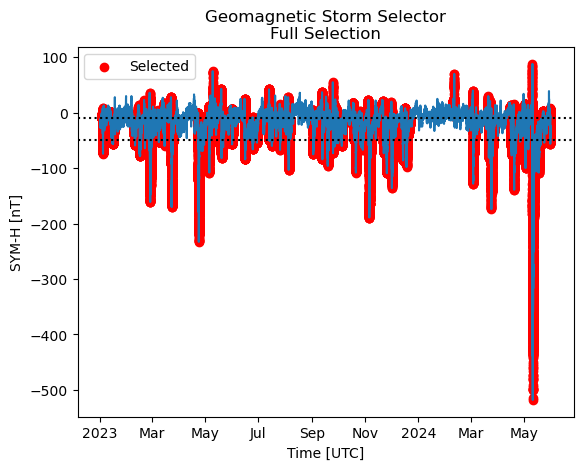

In [10]:
plt.figure()
plt.plot(dat["SYM-H"])
plt.scatter(dat.iloc[inds].index, dat["SYM-H"].iloc[inds], color="r", label="Selected")
plt.axhline(-10, color="k", linestyle=":")
plt.axhline(-50, color="k", linestyle=":")
plt.title("Geomagnetic Storm Selector\nFull Selection")
plt.xlabel("Time [UTC]")
plt.ylabel("SYM-H [nT]")
locator = mdates.AutoDateLocator(minticks=12, maxticks=15)
formatter = mdates.ConciseDateFormatter(locator)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)
plt.legend()
plt.show()

In [11]:
print(
    "Data included:", 100.0 * len(dat["SYM-H"].iloc[inds_neg]) / len(dat["SYM-H"]), "%"
)

Data included: 33.71427036320653 %
